In [1]:
from google.colab import files
uploaded = files.upload()

Saving titanic_cleaned.csv to titanic_cleaned.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [3]:
df = pd.read_csv("titanic_cleaned.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Unknown,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Unknown,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Unknown,Southampton,no,True


In [6]:
print("Shape:", df.shape)
df.info()

Shape: (781, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 781 entries, 0 to 780
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     781 non-null    int64  
 1   pclass       781 non-null    int64  
 2   sex          781 non-null    object 
 3   age          781 non-null    float64
 4   sibsp        781 non-null    int64  
 5   parch        781 non-null    int64  
 6   fare         781 non-null    float64
 7   embarked     781 non-null    object 
 8   class        781 non-null    object 
 9   who          781 non-null    object 
 10  adult_male   781 non-null    bool   
 11  deck         781 non-null    object 
 12  embark_town  781 non-null    object 
 13  alive        781 non-null    object 
 14  alone        781 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 81.0+ KB


In [7]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,781.000000,781.000000,781.000000,781.000000,781.000000,781.000000
mean,0.413572,2.240717,29.622817,0.524968,0.417414,34.750464
std,0.492789,0.855409,13.764671,0.987592,0.838132,52.237906
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,22.000000,0.000000,0.000000,8.050000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,15.900000
75%,1.000000,3.000000,36.000000,1.000000,1.000000,34.020800
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [10]:
df = df[[
    "survived",
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]]

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [12]:
df = pd.get_dummies(
    df,
    columns=["sex", "embarked"],
    drop_first=True
)

In [13]:
df.head()

,survived,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [16]:
df.dtypes

,0
survived,int64
pclass,int64
age,float64
sibsp,int64
parch,int64
fare,float64
sex_male,bool
embarked_Q,bool
embarked_S,bool


In [17]:
x = df.drop("survived", axis=1)
y = df["survived"]

In [18]:
print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: (781, 8)
y shape: (781,)


In [19]:
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.2,random_state=32, stratify=y)

In [21]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [25]:
y_pred = model.predict(x_test)

In [26]:
print(y_pred[:20])

[0 0 1 0 0 1 0 0 1 0 0 0 1 0 0 1 0 1 0 1]


In [27]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.7834394904458599
Accuracy (%): 78.343949044586


In [28]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.7246376811594203
Recall: 0.7692307692307693
F1 Score: 0.746268656716418


In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.79      0.81        92
           1       0.72      0.77      0.75        65

    accuracy                           0.78       157
   macro avg       0.78      0.78      0.78       157
weighted avg       0.79      0.78      0.78       157



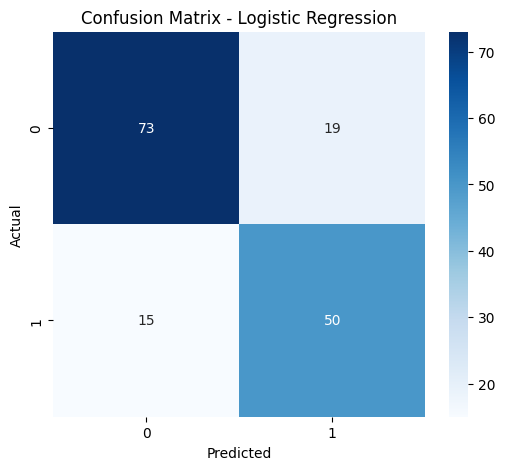

In [30]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [32]:
y_prob = model.predict_proba(x_test)[:, 1]

In [33]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc_score)

ROC-AUC: 0.8535117056856187


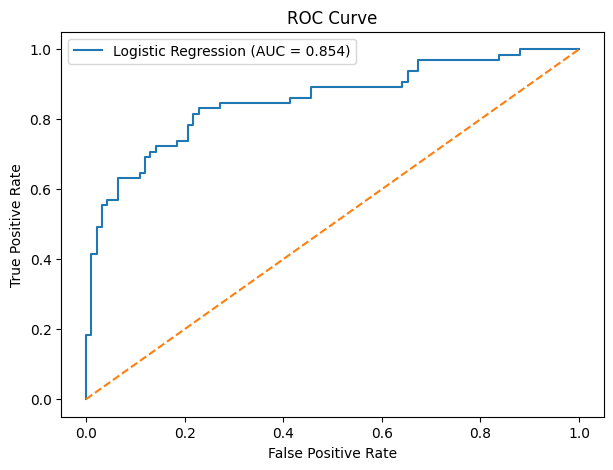

In [34]:
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

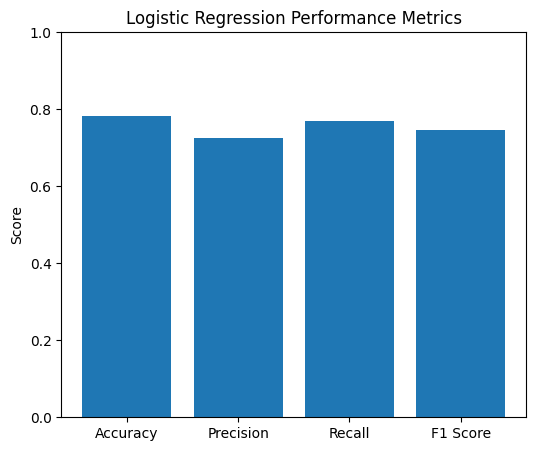

In [37]:
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

plt.figure(figsize=(6, 5))

plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Logistic Regression Performance Metrics")

plt.show()

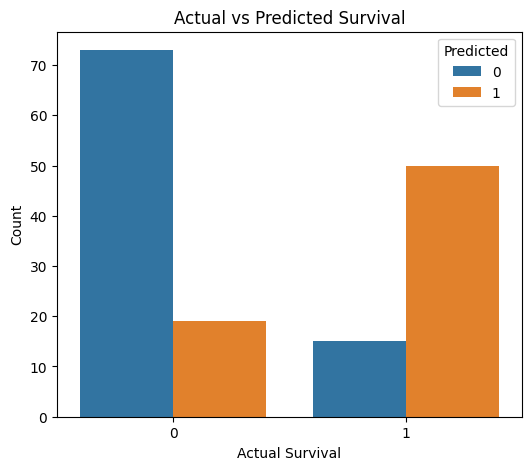

In [39]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

plt.figure(figsize=(6, 5))

sns.countplot(
    data=comparison,
    x="Actual",
    hue="Predicted"
)

plt.title("Actual vs Predicted Survival")
plt.xlabel("Actual Survival")
plt.ylabel("Count")

plt.show()

In [40]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 73
False Positives: 19
False Negatives: 15
True Positives: 50


In [43]:
train_accuracy = model.score(x_train, y_train)
test_accuracy = model.score(x_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.7756410256410257
Testing Accuracy: 0.7834394904458599


In [45]:
feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": model.coef_[0]
})

feature_importance = feature_importance.sort_values(
    "Coefficient",
    ascending=False
)

print(feature_importance)

      Feature  Coefficient
4        fare     0.001358
1         age    -0.033683
3       parch    -0.098312
6  embarked_Q    -0.267725
2       sibsp    -0.323596
7  embarked_S    -0.414752
0      pclass    -0.972475
5    sex_male    -2.463744


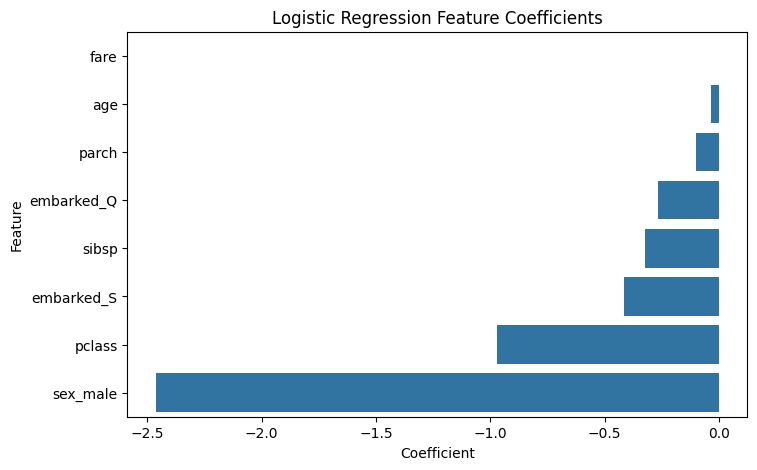

In [46]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Coefficient",
    y="Feature"
)

plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

In [47]:
print("===== FINAL MODEL SUMMARY =====")
print("Model: Logistic Regression")
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", auc_score)

===== FINAL MODEL SUMMARY =====
Model: Logistic Regression
Training Accuracy: 0.7756410256410257
Testing Accuracy: 0.7834394904458599
Precision: 0.7246376811594203
Recall: 0.7692307692307693
F1 Score: 0.746268656716418
ROC-AUC: 0.8535117056856187
